# 시계열 데이터

![time_series1](img/time_series1.png)

- 예시로 주가 예측을 한다고 하면, 매 종가는 이전 종가에 영향을 받는다. 
- 그렇다면 네트워크가 8일차의 종가를 바로 맞춘다면 나와야되는 벡터는 하나의 값만을 반환하는, dim = 1인 벡터이다. 
- 그렇다면 이전 단계의 hidden state도 dim = 1이어야 한다. 
- 입력은 5개인데 dim 1짜리 값으로 차원축소시켜 다음 레이어에 전달해야 한다. 
- 이렇게 모델에 부담을 주는 것 보단, 더 많은 벡터들을 주고받게 하고, 마지막에 Fully Connected Layer를 두고, 마지막 레이어에서 종가를 맞추게 하는 게 더 나을 것 이다.

In [2]:
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [3]:
torch.manual_seed(0)

seq_length = 7
data_dim = 5
hidden_dim = 10
output_dim = 1
lr = 0.01
iterations = 500

xy = np.loadtxt('data-02-stock_daily.csv', delimiter = ',')
xy = xy[::-1]
train_size = int(len(xy) * 0.7)
train_set = xy[0:train_size]
test_set = xy[train_size - seq_length:]

In [10]:
def minmax_scaler(data):
    numerator = data - np.min(data, 0)
    denominator = np.max(data, 0) - np.min(data, 0)
    return numerator / (denominator + 1e-7)

def build_dataset(time_series, seq_length):
    data_x = []
    data_y = []
    
    for i in range(0, len(time_series) - seq_length):
        _x = time_series[i:i+seq_length, :]
        _y = time_series[i + seq_length, [-1]]
        data_x.append(_x)
        data_y.append(_y)
        
    return np.array(data_x), np.array(data_y)

In [12]:
train_set = minmax_scaler(train_set)
test_set = minmax_scaler(test_set)

train_x, train_y = build_dataset(train_set, seq_length)
test_x, test_y = build_dataset(test_set, seq_length)

train_x_tensor = torch.FloatTensor(train_x)
train_y_tensor = torch.FloatTensor(train_y)

test_x_tensor = torch.FloatTensor(test_x)
test_y_tensor = torch.FloatTensor(test_y)


In [13]:
class Net(torch.nn.Module):
    
    def __init__(self, input_dim, hidden_dim, output_dim, layers):
        super(Net, self).__init__()
        self.rnn = torch.nn.LSTM(input_dim, hidden_dim, num_layers = layers, batch_first = True)
        self.rc = torch.nn.Linear(hidden_dim, output_dim, bias=True)
        
    def forward(self, x):
        x, _status = self.rnn(x)
        x = self.rc(x[:, -1])
        return x


In [14]:
net = Net(data_dim, hidden_dim, output_dim, 1)

criterion = torch.nn.MSELoss()
optimizer = optim.Adam(net.parameters(), lr = lr)

0 0.001274443813599646
1 0.0012739845551550388
2 0.0012735276250168681
3 0.0012730727903544903
4 0.0012726198183372617
5 0.0012721691746264696
6 0.001271720277145505
7 0.0012712730094790459
8 0.0012708281865343451
9 0.0012703851098194718
10 0.0012699438957497478
11 0.001269503845833242
12 0.0012690660078078508
13 0.0012686299160122871
14 0.0012681953376159072
15 0.0012677623890340328
16 0.0012673311866819859
17 0.0012669017305597663
18 0.0012664733221754432
19 0.0012660467764362693
20 0.0012656213948503137
21 0.0012651976430788636
22 0.0012647755211219192
23 0.0012643544469028711
24 0.0012639350024983287
25 0.0012635168386623263
26 0.001263099955394864
27 0.00126268423628062
28 0.0012622697977349162
29 0.001261856872588396
30 0.0012614449951797724
31 0.0012610343983396888
32 0.0012606248492375016
33 0.0012602165807038546
34 0.0012598095927387476
35 0.0012594031868502498
36 0.0012589982943609357
37 0.001258594449609518
38 0.0012581913033500314
39 0.0012577896704897285
40 0.0012573887361

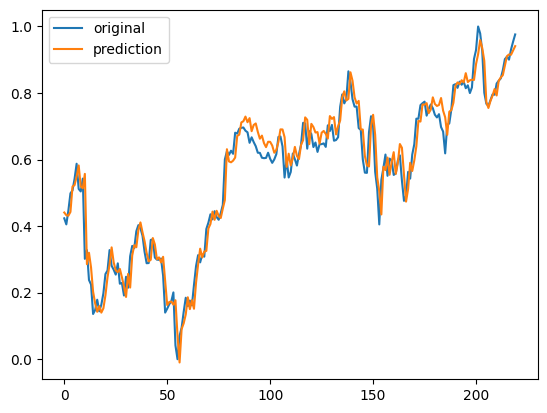

In [16]:
for i in range(iterations):
    optimizer.zero_grad()
    outputs = net(train_x_tensor)
    loss = criterion(outputs, train_y_tensor)
    loss.backward()
    optimizer.step()
    print(i, loss.item())

plt.plot(test_y)
plt.plot(net(test_x_tensor).data.numpy())
plt.legend(['original', 'prediction'])
plt.show()
    